In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import zscore
import pandahouse as ph

In [6]:
connection = {
    'host': 'https://clickhouse.lab.karpov.courses',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator'
}

In [7]:
q = '''SELECT post_id, countIf(action = 'view') AS views, countIf(action = 'like') AS likes
FROM simulator_20250520.feed_actions
GROUP BY post_id'''
df = ph.read_clickhouse(query=q, connection=connection)
df

,post_id,views,likes
0,0,30,2
1,610,725,78
2,4660,15952,2945
3,4742,13059,2492
4,720,25,1
...,...,...,...
6534,3795,3159,397
6535,3099,353,24
6536,3241,16829,2979
6537,3533,1254,123


In [10]:
print("\nОписательная статистика:")
print(df[['views', 'likes']].describe())


Описательная статистика:
               views         likes
count    6539.000000   6539.000000
mean     7801.124025   1645.336902
std     12337.135435   3222.719984
min         1.000000      0.000000
25%       570.000000     51.500000
50%      2859.000000    365.000000
75%      9536.000000   1637.500000
max    118637.000000  32703.000000


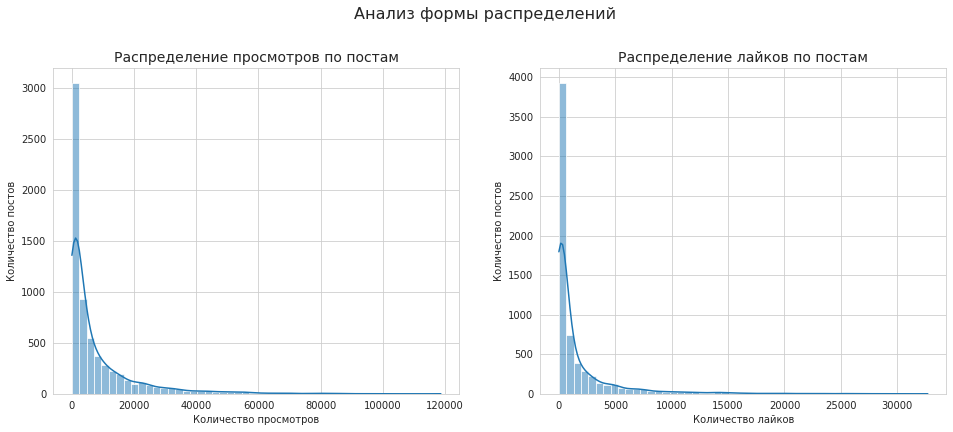

In [11]:
sns.set_style('whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['views'], bins=50, kde=True, ax=ax1)
ax1.set_title('Распределение просмотров по постам', fontsize=14)
ax1.set_xlabel('Количество просмотров')
ax1.set_ylabel('Количество постов')

# Гистограмма для лайков
sns.histplot(df['likes'], bins=50, kde=True, ax=ax2)
ax2.set_title('Распределение лайков по постам', fontsize=14)
ax2.set_xlabel('Количество лайков')
ax2.set_ylabel('Количество постов')

plt.suptitle('Анализ формы распределений', fontsize=16, y=1.02)
plt.show()

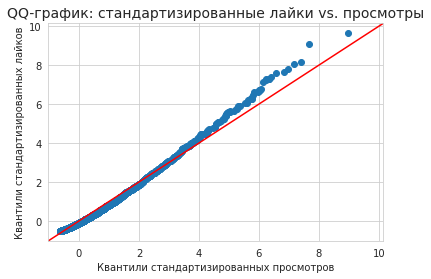

In [12]:
df['views_z'] = zscore(df['views'])
df['likes_z'] = zscore(df['likes'])

fig = sm.qqplot_2samples(
    df['views_z'],
    df['likes_z'],
    line='45'
)
plt.title('QQ-график: стандартизированные лайки vs. просмотры', fontsize=14)
plt.xlabel('Квантили стандартизированных просмотров')
plt.ylabel('Квантили стандартизированных лайков')
plt.grid(True)
plt.show()